In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime
 
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_score, recall_score, f1_score)
 
# =============================================================
# PROJECT 3 — Breast Cancer Classification
# Models   : Logistic Regression, Decision Tree, Random Forest
# Pipeline : sklearn Pipeline + joblib saving
# Eval     : Accuracy, AUC, Precision, Recall, 5-Fold CV
# Dataset  : Wisconsin Breast Cancer (569 samples, 30 features)
# =============================================================
 
os.makedirs("models", exist_ok=True)
 
# ─────────────────────────────────────────────
# STEP 1: Load Data
# ─────────────────────────────────────────────
 
print("=" * 65)
print("STEP 1 — Load and Explore the Data")
print("=" * 65)
 
data   = load_breast_cancer()
X, y   = data.data, data.target
counts = np.bincount(y)
 
print(f"Total samples      : {len(X):,}")
print(f"Number of features : {X.shape[1]}")
print(f"Classes            : {list(data.target_names)}")
print(f"  malignant (0)    : {counts[0]} samples ({counts[0]/len(y)*100:.1f}%)")
print(f"  benign    (1)    : {counts[1]} samples ({counts[1]/len(y)*100:.1f}%)")
 

STEP 1 — Load and Explore the Data
Total samples      : 569
Number of features : 30
Classes            : [np.str_('malignant'), np.str_('benign')]
  malignant (0)    : 212 samples (37.3%)
  benign    (1)    : 357 samples (62.7%)



STEP 2 — Exploratory Data Analysis (EDA)


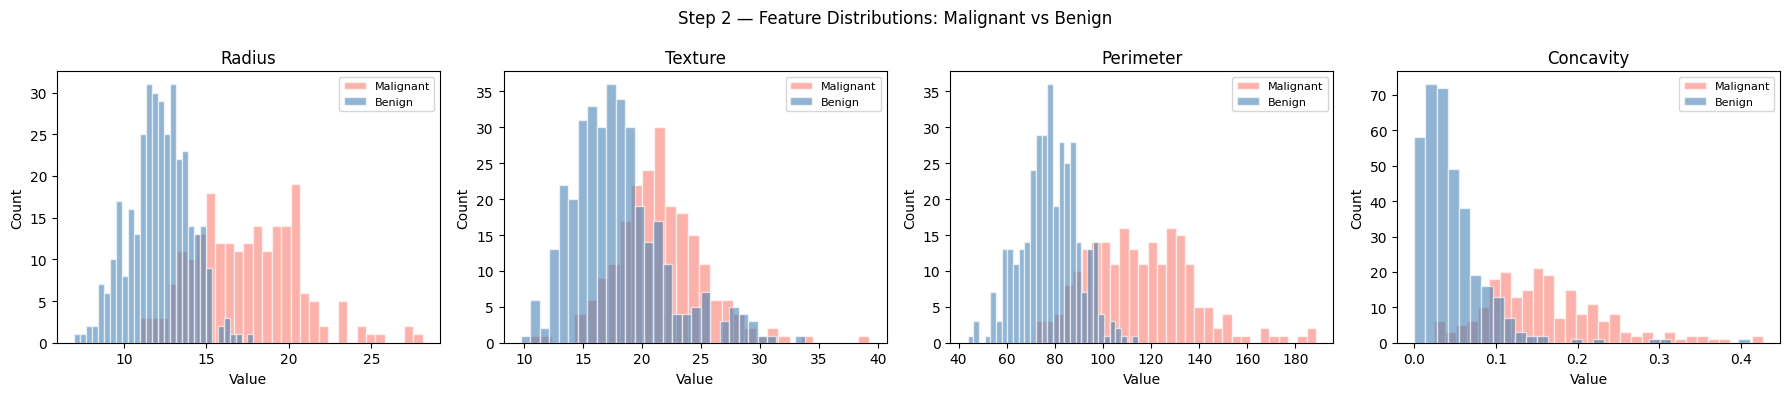

→ Features with clear separation between classes are most useful.


In [2]:
# ─────────────────────────────────────────────
# STEP 2: EDA — Feature Distributions
# Visualize how 4 key features differ across classes.
# Clear separation → feature is useful for classification.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 2 — Exploratory Data Analysis (EDA)")
print("=" * 65)
 
df_eda      = pd.DataFrame(X, columns=data.feature_names)
df_eda['target'] = y
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean concavity']
 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Step 2 — Feature Distributions: Malignant vs Benign", fontsize=12)
for ax, feat in zip(axes, top_features):
    for label, color, name in [(0, 'salmon', 'Malignant'), (1, 'steelblue', 'Benign')]:
        ax.hist(df_eda[df_eda['target'] == label][feat],
                bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(feat.replace('mean ', '').title())
    ax.set_xlabel('Value'); ax.set_ylabel('Count'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("eda_features.png", dpi=150)
plt.show()
print("→ Features with clear separation between classes are most useful.")

In [3]:
# ─────────────────────────────────────────────
# STEP 3: Train / Test Split
# stratify=y → preserves class ratio in both sets.
# Split FIRST, scale AFTER — prevents data leakage.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 3 — Train/Test Split (80/20, stratified)")
print("=" * 65)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]}  samples")
print("Note: scaler is fitted on training data only → no data leakage.")


STEP 3 — Train/Test Split (80/20, stratified)
Training set : 455 samples
Test set     : 114  samples
Note: scaler is fitted on training data only → no data leakage.


In [4]:
# ─────────────────────────────────────────────
# STEP 4: Build sklearn Pipelines for All 3 Models
# A Pipeline chains preprocessing + model into one object.
# Benefits:
#   - No data leakage (scaler fitted inside CV folds automatically)
#   - Clean, reproducible, production-ready
#   - Can be saved as a single .pkl file
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 4 — Building sklearn Pipelines")
print("=" * 65)
 
pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
}
 
print("3 pipelines created:")
for name, pipe in pipelines.items():
    print(f"  • {name:22s} → {pipe.steps}")


STEP 4 — Building sklearn Pipelines
3 pipelines created:
  • Logistic Regression    → [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]
  • Decision Tree          → [('scaler', StandardScaler()), ('model', DecisionTreeClassifier(max_depth=5, random_state=42))]
  • Random Forest          → [('scaler', StandardScaler()), ('model', RandomForestClassifier(random_state=42))]


In [5]:
# ─────────────────────────────────────────────
# STEP 5: Cross Validation (5-Fold)
# Why CV? A single train/test split might be lucky or unlucky.
# 5-Fold CV:
#   - Splits training data into 5 equal parts
#   - Trains 5 times, each time using a different fold as validation
#   - Reports mean ± std → measures model stability
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 5 — 5-Fold Cross Validation")
print("=" * 65)
 
cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
 
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"  {name:22s}  CV = {scores.mean():.3f} ± {scores.std():.3f}  "
          f"(folds: {[f'{s:.3f}' for s in scores]})")
 
print("\n→ Lower std = more stable model across different data splits.")
print("→ Logistic Regression shows highest mean and lowest std → most reliable.")


STEP 5 — 5-Fold Cross Validation
  Logistic Regression     CV = 0.978 ± 0.010  (folds: ['0.967', '0.989', '0.978', '0.989', '0.967'])
  Decision Tree           CV = 0.923 ± 0.012  (folds: ['0.945', '0.923', '0.912', '0.923', '0.912'])
  Random Forest           CV = 0.963 ± 0.018  (folds: ['0.967', '0.956', '0.934', '0.967', '0.989'])

→ Lower std = more stable model across different data splits.
→ Logistic Regression shows highest mean and lowest std → most reliable.


In [6]:
# ─────────────────────────────────────────────
# STEP 6: Train All Models on Full Training Set + Evaluate on Test
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 6 — Training & Test Set Evaluation")
print("=" * 65)
 
results   = {}
roc_data  = {}
 
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
 
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
 
    results[name] = {
        "accuracy":  acc,
        "precision": prec,
        "recall":    rec,
        "f1":        f1,
        "auc":       roc_auc,
        "cv_mean":   cv_results[name].mean(),
        "cv_std":    cv_results[name].std(),
        "y_pred":    y_pred,
        "y_prob":    y_prob,
    }
    roc_data[name] = (fpr, tpr, roc_auc)
 
# Print comparison table
print(f"\n{'Model':<22} {'Accuracy':>9} {'AUC':>7} {'Precision':>10} {'Recall':>8} {'F1':>7} {'CV Mean':>9} {'CV Std':>8}")
print("-" * 85)
for name, r in results.items():
    auc_str = f"{r['auc']:.3f}"
    print(f"  {name:<20} {r['accuracy']:>9.3f} {auc_str:>7} {r['precision']:>10.3f} "
          f"{r['recall']:>8.3f} {r['f1']:>7.3f} {r['cv_mean']:>9.3f} {r['cv_std']:>8.3f}")
 
best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f"\n🏆 Winner: {best_model_name} — highest AUC = {results[best_model_name]['auc']:.3f}, "
      f"CV = {results[best_model_name]['cv_mean']:.3f} ± {results[best_model_name]['cv_std']:.3f}")
 


STEP 6 — Training & Test Set Evaluation

Model                   Accuracy     AUC  Precision   Recall      F1   CV Mean   CV Std
-------------------------------------------------------------------------------------
  Logistic Regression      0.982   0.995      0.986    0.986   0.986     0.978    0.010
  Decision Tree            0.921   0.916      0.957    0.917   0.936     0.923    0.012
  Random Forest            0.956   0.994      0.959    0.972   0.966     0.963    0.018

🏆 Winner: Logistic Regression — highest AUC = 0.995, CV = 0.978 ± 0.010


In [7]:
# ─────────────────────────────────────────────
# STEP 7: Detailed Report for Best Model
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print(f"STEP 7 — Detailed Report: {best_model_name}")
print("=" * 65)
 
best_pred = results[best_model_name]['y_pred']
print(classification_report(y_test, best_pred,
      target_names=['malignant (0)', 'benign (1)']))
 
cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()
print(f"  TN — malignant → malignant (correct) : {tn:3d}  ✅")
print(f"  TP — benign    → benign    (correct) : {tp:3d}  ✅")
print(f"  FP — benign    → malignant (wrong)   : {fp:3d}  ❌  unnecessary alarm")
print(f"  FN — malignant → benign    (missed)  : {fn:3d}  ❌❌ DANGEROUS — missed cancer")
print(f"\n→ In medical diagnosis, FN is the most dangerous error.")
print(f"→ Lowering the classification threshold reduces FN but increases FP.")


STEP 7 — Detailed Report: Logistic Regression
               precision    recall  f1-score   support

malignant (0)       0.98      0.98      0.98        42
   benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114

  TN — malignant → malignant (correct) :  41  ✅
  TP — benign    → benign    (correct) :  71  ✅
  FP — benign    → malignant (wrong)   :   1  ❌  unnecessary alarm
  FN — malignant → benign    (missed)  :   1  ❌❌ DANGEROUS — missed cancer

→ In medical diagnosis, FN is the most dangerous error.
→ Lowering the classification threshold reduces FN but increases FP.



STEP 8 — Visualization


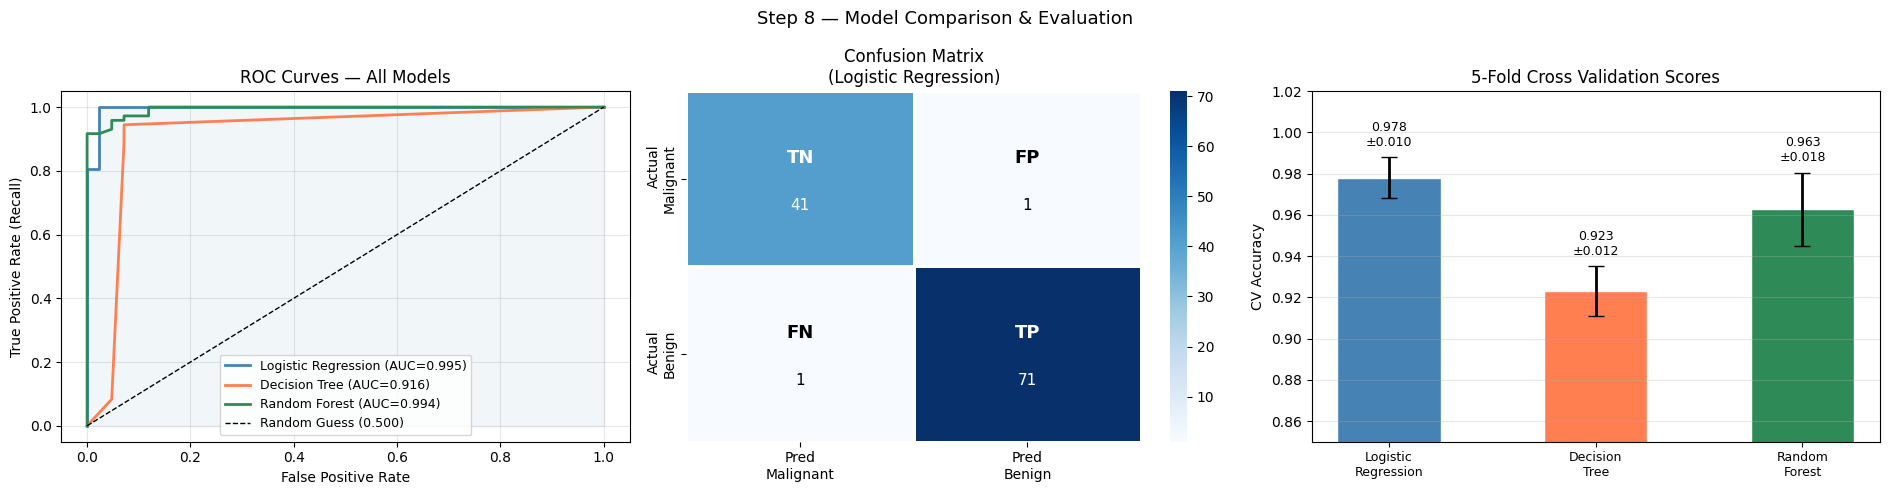

Plot saved → 'model_comparison.png'


In [8]:
# ─────────────────────────────────────────────
# STEP 8: Visualization — All Models Compared
# Plot 1: ROC Curves for all 3 models on same axes
# Plot 2: Confusion Matrix for the best model
# Plot 3: CV scores distribution (box plot)
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 8 — Visualization")
print("=" * 65)
 
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("Step 8 — Model Comparison & Evaluation", fontsize=13)
 
# ── Left: ROC Curves (all 3 models) ──────────
ax1 = axes[0]
colors = {'Logistic Regression': 'steelblue',
          'Decision Tree':       'coral',
          'Random Forest':       'seagreen'}
for name, (fpr, tpr, roc_auc) in roc_data.items():
    ax1.plot(fpr, tpr, color=colors[name], linewidth=2,
             label=f'{name} (AUC={roc_auc:.3f})')
ax1.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Guess (0.500)')
ax1.fill_between(*roc_data[best_model_name][:2], alpha=0.07, color='steelblue')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC Curves — All Models')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
 
# ── Middle: Confusion Matrix (best model) ─────
ax2 = axes[1]
labels_grid = [['TN', 'FP'], ['FN', 'TP']]
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=['Pred\nMalignant', 'Pred\nBenign'],
            yticklabels=['Actual\nMalignant', 'Actual\nBenign'],
            ax=ax2, linewidths=1)
for i in range(2):
    for j in range(2):
        clr = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax2.text(j+0.5, i+0.38, labels_grid[i][j],
                 ha='center', va='center', color=clr, fontsize=13, fontweight='bold')
        ax2.text(j+0.5, i+0.65, str(cm[i,j]),
                 ha='center', va='center', color=clr, fontsize=11)
ax2.set_title(f"Confusion Matrix\n({best_model_name})")
 
# ── Right: CV Score Distribution (bar + error) ─
ax3 = axes[2]
model_names  = list(cv_results.keys())
cv_means     = [cv_results[n].mean() for n in model_names]
cv_stds      = [cv_results[n].std()  for n in model_names]
bar_colors   = [colors[n] for n in model_names]
 
bars = ax3.bar(model_names, cv_means, yerr=cv_stds,
               color=bar_colors, capsize=6,
               edgecolor='white', width=0.5, error_kw={'linewidth': 2})
for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + std + 0.004,
             f"{mean:.3f}\n±{std:.3f}",
             ha='center', va='bottom', fontsize=9)
ax3.set_ylim(0.85, 1.02)
ax3.set_ylabel("CV Accuracy")
ax3.set_title("5-Fold Cross Validation Scores")
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=9)
ax3.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Plot saved → 'model_comparison.png'")

In [9]:
# ─────────────────────────────────────────────
# STEP 9: Save Best Model with joblib
# Why save? So you don't retrain every time.
# The entire Pipeline (scaler + model) is saved as one file.
# Also save metadata JSON for versioning and reproducibility.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 9 — Save Production Pipeline (joblib)")
print("=" * 65)
 
best_pipeline = pipelines[best_model_name]
model_path    = "models/model_v1.pkl"
info_path     = "models/model_v1_info.json"
 
joblib.dump(best_pipeline, model_path)
 
model_info = {
    "model_name":    best_model_name,
    "version":       "v1",
    "saved_at":      datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset":       "Wisconsin Breast Cancer",
    "n_samples":     len(X),
    "n_features":    X.shape[1],
    "feature_names": list(data.feature_names),
    "classes":       list(data.target_names),
    "test_accuracy": round(results[best_model_name]['accuracy'], 4),
    "test_auc":      round(results[best_model_name]['auc'], 4),
    "cv_mean":       round(results[best_model_name]['cv_mean'], 4),
    "cv_std":        round(results[best_model_name]['cv_std'], 4),
    "pipeline_steps": [step[0] for step in best_pipeline.steps],
}
 
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=2)
 
print(f"Pipeline saved  → '{model_path}'")
print(f"Metadata saved  → '{info_path}'")
print(f"\nMetadata contents:")
for k, v in model_info.items():
    if k != "feature_names":
        print(f"  {k:20s}: {v}")


STEP 9 — Save Production Pipeline (joblib)
Pipeline saved  → 'models/model_v1.pkl'
Metadata saved  → 'models/model_v1_info.json'

Metadata contents:
  model_name          : Logistic Regression
  version             : v1
  saved_at            : 2026-04-26 09:09:54
  dataset             : Wisconsin Breast Cancer
  n_samples           : 569
  n_features          : 30
  classes             : [np.str_('malignant'), np.str_('benign')]
  test_accuracy       : 0.9825
  test_auc            : 0.9954
  cv_mean             : 0.978
  cv_std              : 0.0098
  pipeline_steps      : ['scaler', 'model']


In [10]:
# ─────────────────────────────────────────────
# STEP 10: Load Saved Model and Predict on New Patients
# This simulates a production environment where the model
# is loaded from disk and used to classify new data.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 10 — Load Pipeline & Predict New Patients")
print("=" * 65)
 
pipeline = joblib.load(model_path)
print(f"Loaded pipeline from '{model_path}'")
print(f"Pipeline steps: {[s[0] for s in pipeline.steps]}\n")
 
def predict_patient(features_array, label="Patient"):
    """
    Classifies a new patient tumor as malignant or benign.
    Uses the saved production pipeline (scaler + model).
 
    Args:
        features_array (np.ndarray): 1D array of 30 feature values.
        label (str): Patient name/ID for display.
 
    Returns:
        dict: diagnosis, confidence, probabilities.
    """
    pred   = pipeline.predict([features_array])[0]
    proba  = pipeline.predict_proba([features_array])[0]
 
    diagnosis  = "Benign ✅"    if pred == 1 else "Malignant 🚨"
    confidence = proba[pred] * 100
 
    print(f"  {label}")
    print(f"  Diagnosis    : {diagnosis}")
    print(f"  Confidence   : {confidence:.1f}%")
    print(f"  P(malignant) : {proba[0]*100:.1f}%   |   P(benign) : {proba[1]*100:.1f}%")
    print()
    return {"diagnosis": "Benign" if pred==1 else "Malignant", "confidence": confidence}
 
feature_means = X.mean(axis=0)
 
# Patient 1 — average baseline
predict_patient(feature_means, "Patient 1 — Average baseline")
 
# Patient 2 — small radius + low concavity → likely benign
p2 = feature_means.copy()
p2[0] *= 0.65; p2[7] *= 0.50
predict_patient(p2, "Patient 2 — Small radius + low concavity (likely benign)")
 
# Patient 3 — large radius + high concavity → likely malignant
p3 = feature_means.copy()
p3[0] *= 1.65; p3[7] *= 2.3
predict_patient(p3, "Patient 3 — Large radius + high concavity (likely malignant)")


STEP 10 — Load Pipeline & Predict New Patients
Loaded pipeline from 'models/model_v1.pkl'
Pipeline steps: ['scaler', 'model']

  Patient 1 — Average baseline
  Diagnosis    : Benign ✅
  Confidence   : 53.4%
  P(malignant) : 46.6%   |   P(benign) : 53.4%

  Patient 2 — Small radius + low concavity (likely benign)
  Diagnosis    : Benign ✅
  Confidence   : 78.6%
  P(malignant) : 21.4%   |   P(benign) : 78.6%

  Patient 3 — Large radius + high concavity (likely malignant)
  Diagnosis    : Malignant 🚨
  Confidence   : 91.4%
  P(malignant) : 91.4%   |   P(benign) : 8.6%



{'diagnosis': 'Malignant', 'confidence': np.float64(91.37486932732834)}

In [11]:
# ─────────────────────────────────────────────
# STEP 11: Key Learnings Summary
# ─────────────────────────────────────────────
 
print("=" * 65)
print("STEP 11 — Key Learnings")
print("=" * 65)
print("""
  1. Data Leakage Prevention
     → Always split FIRST, then fit scaler on train only.
     → sklearn Pipeline automates this inside CV folds.
 
  2. Cross Validation (5-Fold)
     → More reliable than a single train/test split.
     → Reports mean ± std to measure model stability.
 
  3. Why Logistic Regression beat Random Forest here
     → Data has near-linear relationships between features and target.
     → Simpler model = lower variance = more stable.
     → Occam's Razor: simplest model with best results wins.
 
  4. Bias-Variance Tradeoff
     → Decision Tree (max_depth=5): limited to avoid overfitting.
     → Random Forest (100 trees): reduces variance via averaging.
     → Logistic Regression: inherently low variance on this data.
 
  5. Ensemble Learning
     → Random Forest = 100 Decision Trees voting on the outcome.
     → Majority vote reduces the chance of any single tree being wrong.
 
  6. Critical Medical Tradeoff
     → False Negative (missed cancer) → delayed treatment → WORST outcome.
     → False Positive (healthy flagged) → unnecessary stress → manageable.
     → Therefore: maximize RECALL over Precision in medical applications.
 
  7. AUC Interpretation
     → AUC = 0.995 → near-perfect discrimination ability.
     → AUC = 0.500 → random guessing (baseline).
     → AUC measures ranking quality across all thresholds, not just 0.5.
 
  8. Production Pipeline
     → sklearn Pipeline + joblib: clean, reproducible, deployable.
     → JSON metadata: version tracking, reproducibility.
""")
 
print("=" * 65)
print("✅ All steps complete.")
print("   Saved: 'eda_features.png', 'model_comparison.png'")
print("   Saved: 'models/model_v1.pkl', 'models/model_v1_info.json'")
print("=" * 65)

STEP 11 — Key Learnings

  1. Data Leakage Prevention
     → Always split FIRST, then fit scaler on train only.
     → sklearn Pipeline automates this inside CV folds.

  2. Cross Validation (5-Fold)
     → More reliable than a single train/test split.
     → Reports mean ± std to measure model stability.

  3. Why Logistic Regression beat Random Forest here
     → Data has near-linear relationships between features and target.
     → Simpler model = lower variance = more stable.
     → Occam's Razor: simplest model with best results wins.

  4. Bias-Variance Tradeoff
     → Decision Tree (max_depth=5): limited to avoid overfitting.
     → Random Forest (100 trees): reduces variance via averaging.
     → Logistic Regression: inherently low variance on this data.

  5. Ensemble Learning
     → Random Forest = 100 Decision Trees voting on the outcome.
     → Majority vote reduces the chance of any single tree being wrong.

  6. Critical Medical Tradeoff
     → False Negative (missed canc